# K-Means Clustering & The Silhouette Score

In this notebook, we will explore how K-Means clustering works using `scikit-learn` and evaluate the optimal number of clusters using the **Silhouette Score** instead of the Elbow method.

**Our Goals:**
1. Load and explore the Iris dataset.
2. Calculate the Silhouette Score to determine the optimal number of clusters ($k$).
3. Apply K-Means with our chosen $k$ and visualize the results.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# We will only use the first two features (Sepal Length & Sepal Width)
X = df.iloc[:, [0, 1]].values

print("Dataset shape:", X.shape)
df.head()

Dataset shape: (150, 2)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Finding the Best 'k' using the Silhouette Score

The Silhouette Score peaks at the optimal number of clusters. The score ranges from -1 to 1, where higher values indicate better defined clusters.

*Note: We must start our test range at $k=2$, because the Silhouette Score requires at least two clusters to measure separation.*

The highest silhouette score is at k = 2


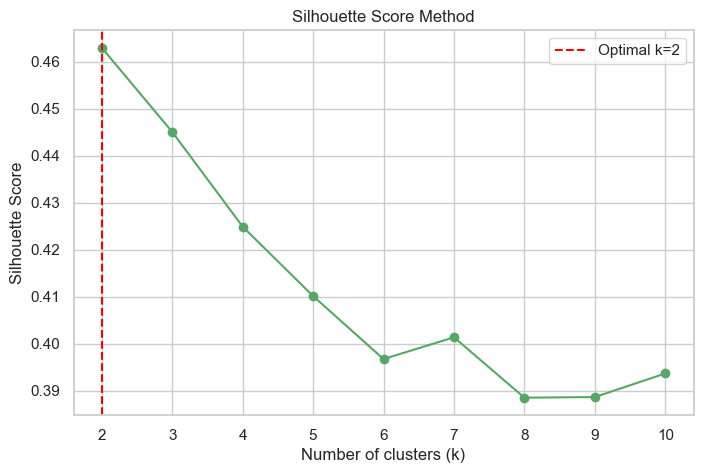

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11) 

for i in k_range:
    # n_init=10 runs the algorithm 10 times with different centroid seeds
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    
    # Calculate silhouette score
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

# Find the k with the highest score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"The highest silhouette score is at k = {optimal_k}")

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='g')
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xticks(k_range)
plt.legend()
plt.show()

## Applying the Optimal 'k'

The graph clearly shows a peak, giving us our optimal number of clusters mathematically without needing to visually guess an "elbow". 

Let's train the final model and visualize the results.

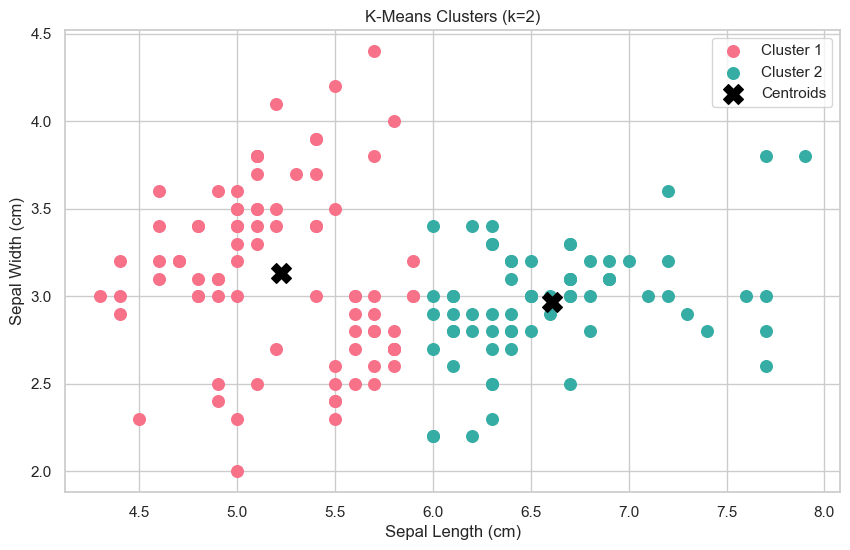

In [6]:
# Apply K-Means with the optimal k
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Visualize the clusters dynamically based on optimal_k
plt.figure(figsize=(10, 6))
colors = sns.color_palette("husl", optimal_k)

for i in range(optimal_k):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], 
                s=70, color=colors[i], label=f'Cluster {i+1}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='black', marker='X', label='Centroids')

plt.title(f'K-Means Clusters (k={optimal_k})')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.show()